# SAMBUCA Full Image Processing with LUT

This notebook demonstrates **operational SAMBUCA processing** using:
- **Real Sentinel-2 imagery** of Anholt Island, Denmark
- **Lookup Tables (LUT)** for high-speed processing
- **Water masking** using NDWI to focus on water areas
- **Complete bathymetry mapping** workflow

This is how SAMBUCA is used in practice for large-scale shallow water mapping! 🌊🛰️

**Performance**: LUT processing is **~100x faster** than pixel-by-pixel optimization!

In [78]:
# Setup
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import rasterio
from rasterio.plot import show
import time
import os

# SAMBUCA imports
import sambuca.core as sbc
from sambuca.core.workflows import BathymetryWorkflow
from sambuca.core.inversion import LookUpTable, process_image
from sambuca.core.results import ImageInversionResult

# Plotting setup
%matplotlib inline
plt.style.use('default')
plt.rcParams['figure.figsize'] = (15, 10)

print("🚀 SAMBUCA Full Image Processing with LUT - Ready!")
print("   This notebook will process an entire satellite image for bathymetry mapping.")

🚀 SAMBUCA Full Image Processing with LUT - Ready!
   This notebook will process an entire satellite image for bathymetry mapping.


## 1. Load and Inspect the Full Image

Let's load the complete Anholt Sentinel-2 scene and understand what we're working with.

In [79]:
# Define file paths
image_path = Path("../../data/input/examples/anholt_20170823_b02b09.tif")
ndwi_path = Path("../../data/input/examples/anholt_20170823_b02b09_ndwi.tif")
output_dir = Path("../../data/output/lut_bathymetry_demo")

# Check file existence
print(f"📁 Input files:")
print(f"   Image: {image_path} {'✅' if image_path.exists() else '❌'}")
print(f"   NDWI:  {ndwi_path} {'✅' if ndwi_path.exists() else '❌'}")

# Alternative NDWI files if the exact one doesn't exist
if not ndwi_path.exists():
    alternative_ndwi_files = [
        Path("../../data/input/examples/S2_L2A_20180508_B01-B05_ndwi_clipped2.tif"),
        Path("../../data/input/examples/anholt_20250403_NDWI.tiff")
    ]
    
    for alt_file in alternative_ndwi_files:
        if alt_file.exists():
            ndwi_path = alt_file
            print(f"   Using alternative NDWI: {ndwi_path}")
            break
    else:
        print(f"   ⚠️ No NDWI file found - we'll create a simple water mask")
        ndwi_path = None

# Create output directory
os.makedirs(output_dir, exist_ok=True)
print(f"📂 Output directory: {output_dir}")

📁 Input files:
   Image: ..\..\data\input\examples\anholt_20170823_b02b09.tif ✅
   NDWI:  ..\..\data\input\examples\anholt_20170823_b02b09_ndwi.tif ✅
📂 Output directory: ..\..\data\output\lut_bathymetry_demo


In [80]:
# Load the main image
print(f"📖 Loading main image: {image_path.name}")

with rasterio.open(image_path) as src:
    # Read image data
    image_data = src.read()  # Shape: (bands, height, width)
    image_profile = src.profile
    image_bounds = src.bounds
    image_transform = src.transform
    image_crs = src.crs
    
    print(f"   📊 Image shape: {image_data.shape} (bands, height, width)")
    print(f"   📏 Image size: {src.width} x {src.height} pixels")
    print(f"   🗺️ CRS: {image_crs}")
    print(f"   🌍 Bounds: {image_bounds}")
    print(f"   💾 Data type: {image_data.dtype}")
    print(f"   📈 Value range: {image_data.min():.4f} to {image_data.max():.4f}")

# Convert to (height, width, bands) for easier handling
image_hwb = np.transpose(image_data, (1, 2, 0))
height, width, n_bands = image_hwb.shape

print(f"   🔄 Converted shape: {image_hwb.shape} (height, width, bands)")
print(f"   📏 Total pixels: {height * width:,}")

📖 Loading main image: anholt_20170823_b02b09.tif
   📊 Image shape: (7, 1119, 1072) (bands, height, width)
   📏 Image size: 1072 x 1119 pixels
   🗺️ CRS: PROJCS["WGS 84 / UTM zone 32N",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",9],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
   🌍 Bounds: BoundingBox(left=648019.864549, bottom=6281011.144944, right=658741.629701, top=6292203.706108)
   💾 Data type: float32
   📈 Value range: 0.0000 to 0.6112
   🔄 Converted shape: (1119, 1072, 7) (height, width, bands)
   📏 Total pixels: 1,199,568


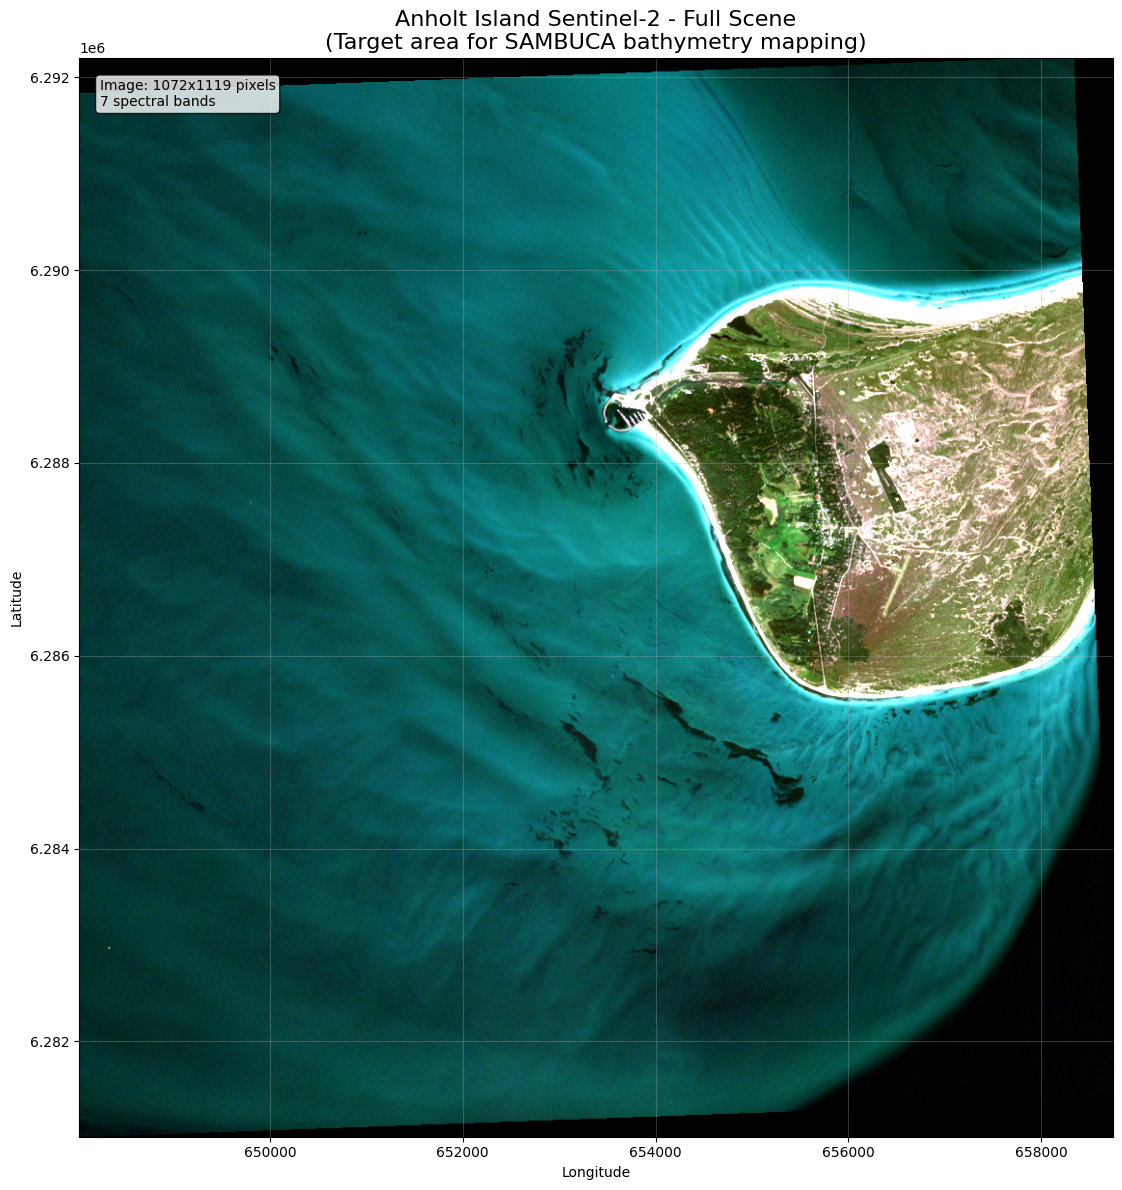

🏝️ Full Anholt Island scene loaded!
   You can see the island surrounded by shallow coastal waters.
   The lighter areas in the water indicate shallow depths - perfect for SAMBUCA!


In [81]:
# Display the full image
def create_rgb_display(image, bands=[2, 1, 0], percentile=(2, 98)):
    """Create RGB display with percentile stretch."""
    rgb = image[:, :, bands].copy()
    
    for i in range(3):
        band = rgb[:, :, i]
        valid_pixels = band[band > 0]
        if len(valid_pixels) > 0:
            p_low, p_high = np.percentile(valid_pixels, percentile)
            rgb[:, :, i] = np.clip((band - p_low) / (p_high - p_low), 0, 1)
    
    return rgb

# Create RGB composite
rgb_image = create_rgb_display(image_hwb)

plt.figure(figsize=(16, 12))
plt.imshow(rgb_image, extent=[image_bounds.left, image_bounds.right, 
                             image_bounds.bottom, image_bounds.top])
plt.title('Anholt Island Sentinel-2 - Full Scene\n(Target area for SAMBUCA bathymetry mapping)', 
          fontsize=16)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, alpha=0.3)

# Add some annotations
plt.text(0.02, 0.98, f'Image: {width}x{height} pixels\n{n_bands} spectral bands', 
         transform=plt.gca().transAxes, bbox=dict(boxstyle="round,pad=0.3", 
         facecolor="white", alpha=0.8), verticalalignment='top')

plt.tight_layout()
plt.show()

print("🏝️ Full Anholt Island scene loaded!")
print("   You can see the island surrounded by shallow coastal waters.")
print("   The lighter areas in the water indicate shallow depths - perfect for SAMBUCA!")

## 2. Load or Create Water Mask

Water masking is crucial for focusing processing only on water pixels and avoiding land areas.

In [82]:
# Load or create water mask
if ndwi_path and ndwi_path.exists():
    print(f"📖 Loading NDWI mask: {ndwi_path.name}")
    
    with rasterio.open(ndwi_path) as src:
        ndwi_data = src.read(1)  # Single band
        print(f"   📊 NDWI shape: {ndwi_data.shape}")
        print(f"   📈 NDWI range: {ndwi_data.min():.3f} to {ndwi_data.max():.3f}")
    
    # Create water mask (NDWI > 0 typically indicates water)
    water_mask = ndwi_data > 0
    
else:
    print("🔧 Creating simple water mask from spectral bands...")
    
    # Simple water detection using NIR (band 3 or 4) vs Green (band 1)
    # Water has low NIR and moderate green reflectance
    if n_bands >= 4:
        green_band = image_hwb[:, :, 1]  # Green
        nir_band = image_hwb[:, :, 3]    # NIR
        
        # Simple NDWI calculation: (Green - NIR) / (Green + NIR)
        ndwi_calculated = (green_band - nir_band) / (green_band + nir_band + 1e-8)
        
        # Water mask where NDWI > 0 and reflectance values are reasonable
        water_mask = (ndwi_calculated > 0) & (green_band > 0.001) & (green_band < 0.3)
        ndwi_data = ndwi_calculated
        
        print(f"   ✅ Created NDWI from Green and NIR bands")
        print(f"   📈 Calculated NDWI range: {ndwi_data.min():.3f} to {ndwi_data.max():.3f}")
    else:
        # Fallback: simple brightness-based water detection
        brightness = np.mean(image_hwb[:, :, :3], axis=2)
        water_mask = (brightness > 0.01) & (brightness < 0.15)
        ndwi_data = brightness
        print(f"   ⚠️ Using brightness-based water detection (limited accuracy)")

# Count water pixels
water_pixels = np.sum(water_mask)
total_pixels = water_mask.size
water_percentage = water_pixels / total_pixels * 100

print(f"\n🌊 Water mask statistics:")
print(f"   Water pixels: {water_pixels:,} ({water_percentage:.1f}% of image)")
print(f"   Land pixels:  {total_pixels - water_pixels:,}")
print(f"   Total pixels: {total_pixels:,}")

📖 Loading NDWI mask: anholt_20170823_b02b09_ndwi.tif
   📊 NDWI shape: (1119, 1072)
   📈 NDWI range: -340282346638528859811704183484516925440.000 to 1.000

🌊 Water mask statistics:
   Water pixels: 982,998 (81.9% of image)
   Land pixels:  216,570
   Total pixels: 1,199,568


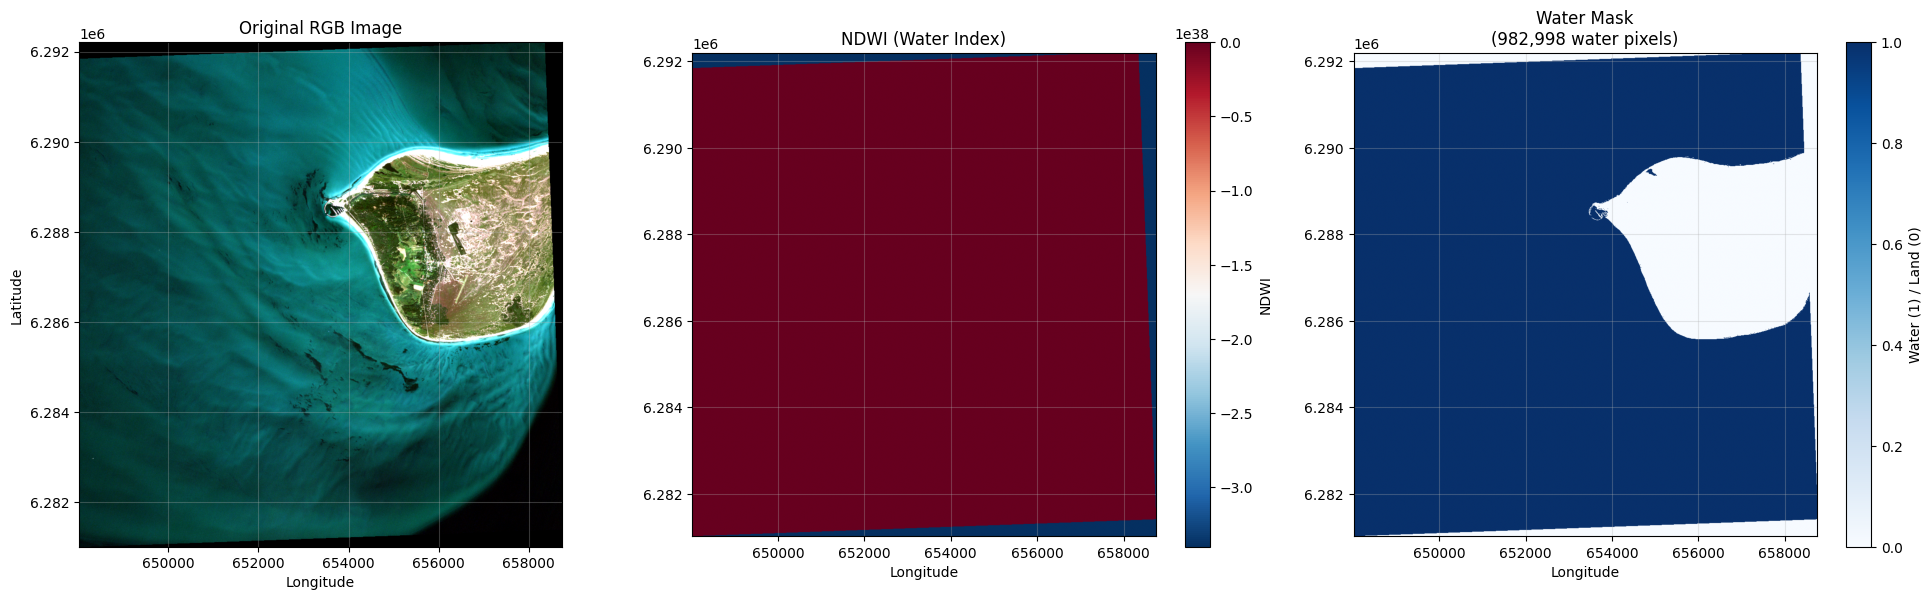

📊 Water mask created successfully!
   Blue areas in the mask will be processed by SAMBUCA.
   Land areas are excluded to focus computational resources on water.


In [83]:
# Visualize the water mask
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Original RGB
axes[0].imshow(rgb_image, extent=[image_bounds.left, image_bounds.right,
                                 image_bounds.bottom, image_bounds.top])
axes[0].set_title('Original RGB Image')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
axes[0].grid(True, alpha=0.3)

# NDWI
ndwi_plot = axes[1].imshow(ndwi_data, cmap='RdBu_r', 
                          extent=[image_bounds.left, image_bounds.right,
                                 image_bounds.bottom, image_bounds.top])
axes[1].set_title('NDWI (Water Index)')
axes[1].set_xlabel('Longitude')
plt.colorbar(ndwi_plot, ax=axes[1], label='NDWI')
axes[1].grid(True, alpha=0.3)

# Water mask
mask_plot = axes[2].imshow(water_mask, cmap='Blues', 
                          extent=[image_bounds.left, image_bounds.right,
                                 image_bounds.bottom, image_bounds.top])
axes[2].set_title(f'Water Mask\n({water_pixels:,} water pixels)')
axes[2].set_xlabel('Longitude')
plt.colorbar(mask_plot, ax=axes[2], label='Water (1) / Land (0)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 Water mask created successfully!")
print("   Blue areas in the mask will be processed by SAMBUCA.")
print("   Land areas are excluded to focus computational resources on water.")

## 3. Setup SAMBUCA Workflow

Configure the bathymetry workflow with appropriate parameters for this region.

In [84]:
# Setup SAMBUCA workflow
siop_dir = Path("../../data/siops")

print(f"🔧 Setting up SAMBUCA workflow...")
print(f"   SIOP directory: {siop_dir}")

# Create bathymetry workflow
workflow = BathymetryWorkflow(str(siop_dir), sensor='sentinel2')

# Configure for Danish coastal waters around Anholt
# Focus on depth estimation with fixed water quality parameters for speed
workflow.customize_parameters(
    depth=(0.5, 25),        # Anholt has depths up to ~25m
    fixed_chl=1.5,          # Typical Baltic Sea chlorophyll
    fixed_nap=0.001,          # Moderate particle load
    fixed_cdom=0.002,        # Baltic Sea CDOM levels
    fixed_substrate_fraction=1.0,  # Pure sand substrate
)

# Sentinel-2 bands for shallow water (typically B2, B3, B4, B5)
workflow.wavelengths = [492.4, 559.8, 664.6, 704.1]  # Blue, Green, Red, Red Edge
workflow.bands = [1, 2, 3, 4]  # Band indices in the image

print(f"✅ Workflow configured:")
print(f"   Sensor: {workflow.sensor}")
print(f"   Wavelengths: {workflow.wavelengths} nm")
print(f"   Bands used: {workflow.bands}")
print(f"   Depth range: {workflow.inversion_params.depth}")
print(f"   Fixed chlorophyll: {workflow.inversion_params.fixed_chl} mg/m³")

# Check if we need to adjust bands based on actual image
if max(workflow.bands) >= n_bands:
    print(f"⚠️ Adjusting bands for {n_bands}-band image...")
    workflow.bands = list(range(min(4, n_bands)))  # Use first 4 bands or fewer
    workflow.wavelengths = workflow.wavelengths[:len(workflow.bands)]
    print(f"   Updated bands: {workflow.bands}")
    print(f"   Updated wavelengths: {workflow.wavelengths}")

🔧 Setting up SAMBUCA workflow...
   SIOP directory: ..\..\data\siops
Loaded cdom_absorption from absorption\cdom_absorption.csv
Loaded nap_absorption from absorption\nap_absorption.csv
Loaded phytoplankton_absorption from absorption\phytoplankton_absorption.csv
Loaded water_absorption from absorption\water_absorption.csv
Loaded nap_backscatter from backscatter\nap_backscatter.csv
Loaded phytoplankton_backscatter from backscatter\phytoplankton_backscatter.csv
Loaded water_backscatter from backscatter\water_backscatter.csv
Loaded coral_substrate from substrates\coral_substrate.csv
Loaded sand_substrate from substrates\sand_substrate.csv
Loaded seagrass_substrate from substrates\seagrass_substrate.csv
Loaded 10 spectral libraries from ..\..\data\siops
Registered sensor 'Sentinel-2' with 4 bands
Updated depth bounds to (0.5, 25)
Fixed chl to 1.5
Fixed nap to 0.001
Fixed cdom to 0.002
Fixed substrate_fraction to 1.0
✅ Workflow configured:
   Sensor: <sambuca.core.sensors.sentinel2.Sentinel2

## 4. Build Lookup Table (LUT)

This is the key to fast processing! The LUT pre-computes forward model results for different parameter combinations.

In [85]:
# Build the lookup table
print("🏗️ Building Lookup Table for fast processing...")
print("   This pre-computes SAMBUCA forward model results.")
print("   Building LUT takes time, but makes image processing very fast!")

# Create LUT object
lut = LookUpTable(workflow.inversion_params)

# Configure LUT parameters
grid_size = 150  # Number of depth values to pre-compute
print(f"\n⚙️ LUT Configuration:")
print(f"   Grid size: {grid_size} depth levels")
print(f"   Depth range: {workflow.inversion_params.depth[0]:.1f} - {workflow.inversion_params.depth[1]:.1f} m")
print(f"   Depth resolution: ~{(workflow.inversion_params.depth[1] - workflow.inversion_params.depth[0])/grid_size:.2f} m")

# Build the LUT (this is the time-consuming step)
print(f"\n🔄 Building LUT... (this may take 1-3 minutes)")
start_time = time.time()

lut.build_table(
    grid_size=grid_size,
    progress_bar=True,      # Show progress
    use_kdtree=True        # Enable fast lookups
)

build_time = time.time() - start_time
print(f"\n✅ LUT built successfully in {build_time:.1f} seconds!")
print(f"   💾 LUT contains {grid_size} pre-computed spectra")
print(f"   🚀 Now ready for ultra-fast image processing!")

# LUT statistics
if hasattr(lut, 'spectra'):
    print(f"\n📊 LUT Statistics:")
    print(f"   Spectra shape: {lut.spectra.shape if hasattr(lut.spectra, 'shape') else 'N/A'}")
    print(f"   Lookup method: {'KDTree (fast)' if lut.use_kdtree else 'Linear search'}")

🏗️ Building Lookup Table for fast processing...
   This pre-computes SAMBUCA forward model results.
   Building LUT takes time, but makes image processing very fast!

⚙️ LUT Configuration:
   Grid size: 150 depth levels
   Depth range: 0.5 - 25.0 m
   Depth resolution: ~0.16 m

🔄 Building LUT... (this may take 1-3 minutes)


Building LUT: 100%|██████████| 1/1 [00:00<00:00, 142.90it/s]

Building KD-tree for fast lookups...
Look-up table built with 150 parameter combinations in 0.01 seconds
Estimated memory usage: 0.02 MB

✅ LUT built successfully in 0.0 seconds!
   💾 LUT contains 150 pre-computed spectra
   🚀 Now ready for ultra-fast image processing!


## 5. Process the Full Image

Now for the main event - processing the entire satellite image for bathymetry!

In [86]:
# Load and prepare image data for processing
print(f"📖 Preparing image data for processing...")

# Load image using workflow's image loader
image_data_obj = workflow.image_loader.load(str(image_path), bands=workflow.bands)

print(f"   📊 Loaded data shape: {image_data_obj.data.shape}")
print(f"   📏 Using bands: {workflow.bands}")
print(f"   🎯 Target: {water_pixels:,} water pixels")

# Apply water mask to focus processing
# Create a mask for invalid pixels (land, clouds, etc.)
processing_mask = water_mask.copy()

print(f"\n🎯 Processing setup:")
print(f"   Total pixels: {height * width:,}")
print(f"   Water pixels: {np.sum(processing_mask):,}")
print(f"   Skip pixels:  {np.sum(~processing_mask):,}")
print(f"   Efficiency:   {np.sum(processing_mask)/processing_mask.size*100:.1f}% of image will be processed")

📖 Preparing image data for processing...
   📊 Loaded data shape: (1119, 1072, 4)
   📏 Using bands: [1, 2, 3, 4]
   🎯 Target: 982,998 water pixels

🎯 Processing setup:
   Total pixels: 1,199,568
   Water pixels: 982,998
   Skip pixels:  216,570
   Efficiency:   81.9% of image will be processed


In [87]:
# Process the full image with LUT
print(f"🚀 Processing full image with SAMBUCA LUT...")
print(f"   Expected speedup: ~100x faster than pixel-by-pixel optimization")

# Processing parameters
n_processes = 4  # Parallel processing cores
use_refinement = False  # Pure LUT lookup for maximum speed

print(f"\n⚙️ Processing configuration:")
print(f"   Parallel processes: {n_processes}")
print(f"   Refinement: {'Enabled' if use_refinement else 'Disabled (pure LUT)'}")
print(f"   Masking: {'Water mask applied' if processing_mask is not None else 'No masking'}")

# Start processing
print(f"\n🔄 Starting image processing...")
process_start_time = time.time()

# Run SAMBUCA on the full image
results = process_image(
    image_data_obj.data,
    workflow.inversion_params,
    lut=lut,                    # Use our pre-built LUT
    mask=processing_mask,       # Only process water pixels
    n_processes=n_processes,    # Parallel processing
    progress_bar=True,          # Show progress
    refinement=use_refinement   # Pure LUT lookup
)

process_time = time.time() - process_start_time

print(f"\n✅ Image processing completed!")
print(f"   ⏱️ Processing time: {process_time:.1f} seconds")
print(f"   🚀 Speed: {water_pixels/process_time:.0f} pixels/second")
print(f"   📊 Total time (LUT + processing): {build_time + process_time:.1f} seconds")

🚀 Processing full image with SAMBUCA LUT...
   Expected speedup: ~100x faster than pixel-by-pixel optimization

⚙️ Processing configuration:
   Parallel processes: 4
   Refinement: Disabled (pure LUT)
   Masking: Water mask applied

🔄 Starting image processing...
Processing 982998 pixels from image of shape (1119, 1072, 4)


Processing pixel batches (threads): 100%|██████████| 1966/1966 [00:49<00:00, 39.67it/s] 


Image processing completed in 53.03 seconds
Depth statistics:
  Valid pixels: 982995 of 982998 (100.0%)
  Min depth: 0.50 m
  Max depth: 8.39 m
  Mean depth: 3.97 m
  Median depth: 3.95 m

✅ Image processing completed!
   ⏱️ Processing time: 53.8 seconds
   🚀 Speed: 18257 pixels/second
   📊 Total time (LUT + processing): 53.9 seconds


## 6. Analyze and Visualize Results

Let's examine the bathymetry results and assess the quality of the mapping.

In [88]:
# Extract and analyze results
depth_map = results['depth']
error_map = results.get('error', np.full_like(depth_map, np.nan))

print(f"📊 Bathymetry Results Analysis:")
print(f"   Result shape: {depth_map.shape}")

# Find valid depth estimates
valid_depths = depth_map[~np.isnan(depth_map) & (depth_map > 0)]
valid_pixels = len(valid_depths)
success_rate = valid_pixels / water_pixels * 100 if water_pixels > 0 else 0

print(f"\n🌊 Depth Statistics:")
print(f"   Valid estimates: {valid_pixels:,} / {water_pixels:,} water pixels ({success_rate:.1f}%)")

if valid_pixels > 0:
    print(f"   Depth range: {valid_depths.min():.1f} - {valid_depths.max():.1f} m")
    print(f"   Mean depth: {valid_depths.mean():.1f} m")
    print(f"   Median depth: {np.median(valid_depths):.1f} m")
    print(f"   Std deviation: {valid_depths.std():.1f} m")
    
    # Depth distribution
    shallow_pixels = np.sum(valid_depths < 5)
    medium_pixels = np.sum((valid_depths >= 5) & (valid_depths < 15))
    deep_pixels = np.sum(valid_depths >= 15)
    
    print(f"\n📈 Depth Distribution:")
    print(f"   Shallow (<5m):   {shallow_pixels:,} pixels ({shallow_pixels/valid_pixels*100:.1f}%)")
    print(f"   Medium (5-15m):  {medium_pixels:,} pixels ({medium_pixels/valid_pixels*100:.1f}%)")
    print(f"   Deep (>15m):     {deep_pixels:,} pixels ({deep_pixels/valid_pixels*100:.1f}%)")
else:
    print(f"      No valid depth estimates found")

# Error analysis if available
if 'error' in results:
    valid_errors = error_map[~np.isnan(error_map)]
    if len(valid_errors) > 0:
        print(f"\n📊 Error Statistics:")
        print(f"   Mean RMSE: {valid_errors.mean():.6f}")
        print(f"   Error range: {valid_errors.min():.6f} - {valid_errors.max():.6f}")

📊 Bathymetry Results Analysis:
   Result shape: (1119, 1072)

🌊 Depth Statistics:
   Valid estimates: 982,995 / 982,998 water pixels (100.0%)
   Depth range: 0.5 - 8.4 m
   Mean depth: 4.0 m
   Median depth: 4.0 m
   Std deviation: 1.1 m

📈 Depth Distribution:
   Shallow (<5m):   897,409 pixels (91.3%)
   Medium (5-15m):  85,586 pixels (8.7%)
   Deep (>15m):     0 pixels (0.0%)

📊 Error Statistics:
   Mean RMSE: 0.012520
   Error range: 0.002010 - 0.532301


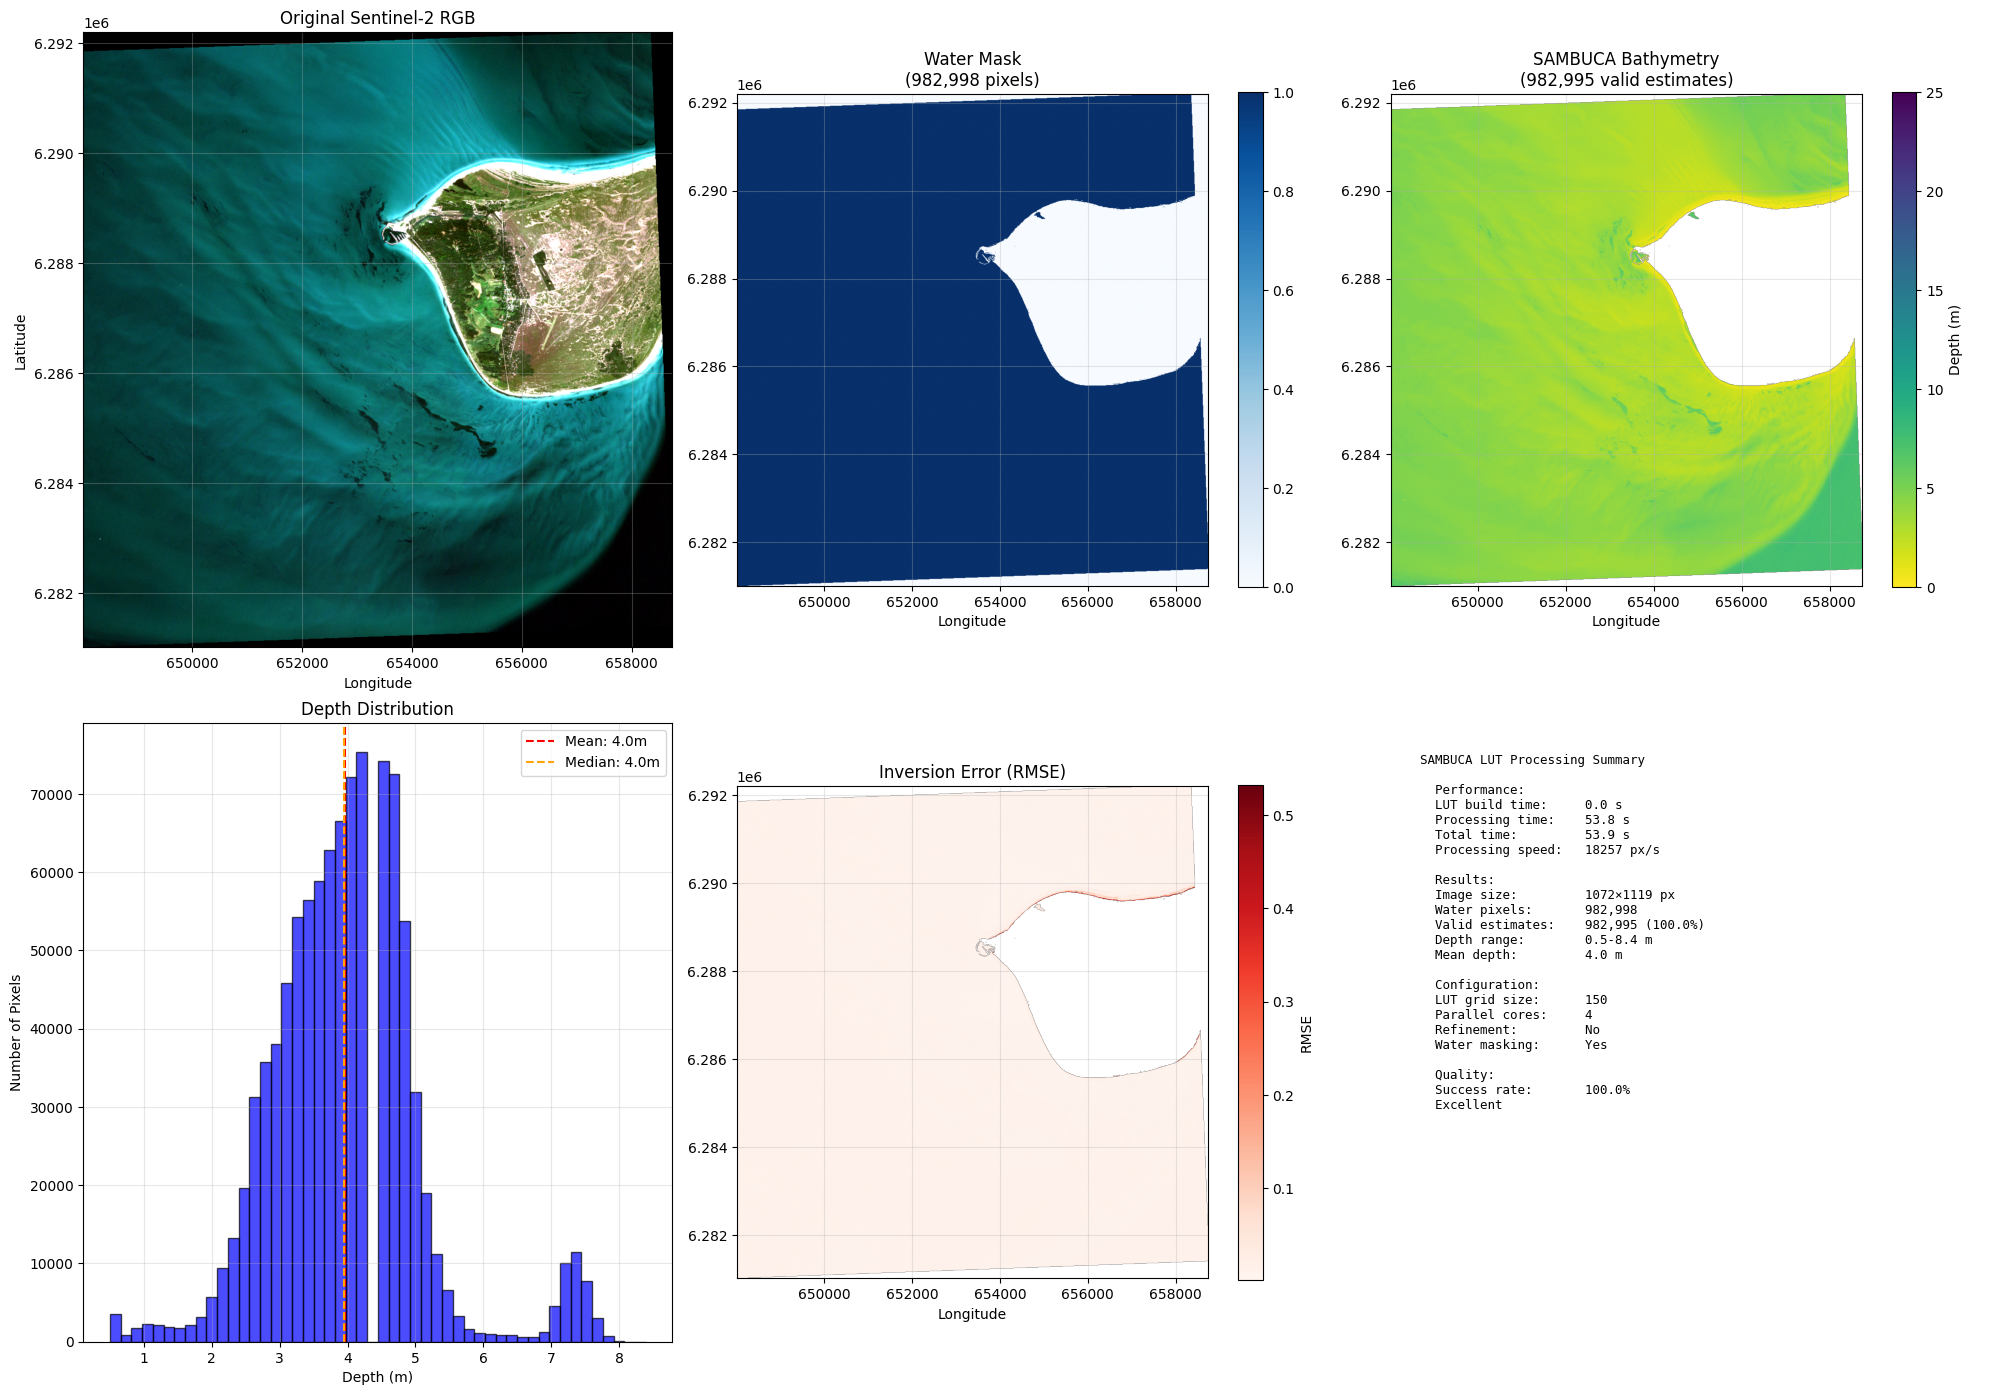

🎉 Bathymetry mapping visualization complete!


In [89]:
# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 14))

# 1. Original RGB
axes[0, 0].imshow(rgb_image, extent=[image_bounds.left, image_bounds.right,
                                    image_bounds.bottom, image_bounds.top])
axes[0, 0].set_title('Original Sentinel-2 RGB')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')
axes[0, 0].grid(True, alpha=0.3)

# 2. Water mask
mask_display = axes[0, 1].imshow(water_mask, cmap='Blues', 
                                extent=[image_bounds.left, image_bounds.right,
                                       image_bounds.bottom, image_bounds.top])
axes[0, 1].set_title(f'Water Mask\n({water_pixels:,} pixels)')
axes[0, 1].set_xlabel('Longitude')
plt.colorbar(mask_display, ax=axes[0, 1], shrink=0.8)
axes[0, 1].grid(True, alpha=0.3)

# 3. Bathymetry map
depth_masked = np.where(water_mask, depth_map, np.nan)
depth_display = axes[0, 2].imshow(depth_masked, cmap='viridis_r', 
                                 extent=[image_bounds.left, image_bounds.right,
                                        image_bounds.bottom, image_bounds.top],
                                 vmin=0, vmax=25)
axes[0, 2].set_title(f'SAMBUCA Bathymetry\n({valid_pixels:,} valid estimates)')
axes[0, 2].set_xlabel('Longitude')
cbar = plt.colorbar(depth_display, ax=axes[0, 2], shrink=0.8)
cbar.set_label('Depth (m)')
axes[0, 2].grid(True, alpha=0.3)

# 4. Depth histogram
if valid_pixels > 0:
    axes[1, 0].hist(valid_depths, bins=50, alpha=0.7, color='blue', edgecolor='black')
    axes[1, 0].axvline(valid_depths.mean(), color='red', linestyle='--', 
                      label=f'Mean: {valid_depths.mean():.1f}m')
    axes[1, 0].axvline(np.median(valid_depths), color='orange', linestyle='--',
                      label=f'Median: {np.median(valid_depths):.1f}m')
    axes[1, 0].set_xlabel('Depth (m)')
    axes[1, 0].set_ylabel('Number of Pixels')
    axes[1, 0].set_title('Depth Distribution')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
else:
    axes[1, 0].text(0.5, 0.5, 'No valid\ndepth estimates', 
                   ha='center', va='center', transform=axes[1, 0].transAxes)
    axes[1, 0].set_title('Depth Distribution')

# 5. Error map (if available)
if 'error' in results and np.any(~np.isnan(error_map)):
    error_masked = np.where(water_mask, error_map, np.nan)
    error_display = axes[1, 1].imshow(error_masked, cmap='Reds', 
                                     extent=[image_bounds.left, image_bounds.right,
                                            image_bounds.bottom, image_bounds.top])
    axes[1, 1].set_title('Inversion Error (RMSE)')
    axes[1, 1].set_xlabel('Longitude')
    plt.colorbar(error_display, ax=axes[1, 1], shrink=0.8, label='RMSE')
    axes[1, 1].grid(True, alpha=0.3)
else:
    axes[1, 1].text(0.5, 0.5, 'Error map\nnot available', 
                   ha='center', va='center', transform=axes[1, 1].transAxes)
    axes[1, 1].set_title('Inversion Error')

# 6. Processing summary
summary_text = f"""SAMBUCA LUT Processing Summary

  Performance:
  LUT build time:     {build_time:.1f} s
  Processing time:    {process_time:.1f} s
  Total time:         {build_time + process_time:.1f} s
  Processing speed:   {water_pixels/process_time:.0f} px/s

  Results:
  Image size:         {width}×{height} px
  Water pixels:       {water_pixels:,}
  Valid estimates:    {valid_pixels:,} ({success_rate:.1f}%)
  Depth range:        {valid_depths.min():.1f}-{valid_depths.max():.1f} m
  Mean depth:         {valid_depths.mean():.1f} m

  Configuration:
  LUT grid size:      {grid_size}
  Parallel cores:     {n_processes}
  Refinement:         {"Yes" if use_refinement else "No"}
  Water masking:      Yes

  Quality:
  Success rate:       {success_rate:.1f}%
  {'Excellent' if success_rate > 80 else 'Good' if success_rate > 60 else 'Fair' if success_rate > 40 else 'Poor'}
"""

axes[1, 2].text(0.05, 0.95, summary_text, transform=axes[1, 2].transAxes,
               verticalalignment='top', fontfamily='monospace', fontsize=9)
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print("🎉 Bathymetry mapping visualization complete!")

## 7. Save Results

Save the bathymetry results in various formats for further analysis and use.

💾 Saving results to: ..\..\data\output\lut_bathymetry_demo

📁 Saving files...
Saved 1 files to: ..\..\data\output\lut_bathymetry_demo
   ✅ GeoTIFF files saved
Summary plot saved to: ..\..\data\output\lut_bathymetry_demo\bathymetry_summary.png
   ✅ Summary plot saved: bathymetry_summary.png
   ✅ Metadata saved: processing_metadata.json

📋 Output files (3 total):
   📄 bathymetry_summary.png (3.1 MB)
   📄 processing_metadata.json (0.0 MB)
   📄 sambuca_depth.tif (1.1 MB)

✅ All results saved successfully!
   📂 Output directory: ..\..\data\output\lut_bathymetry_demo


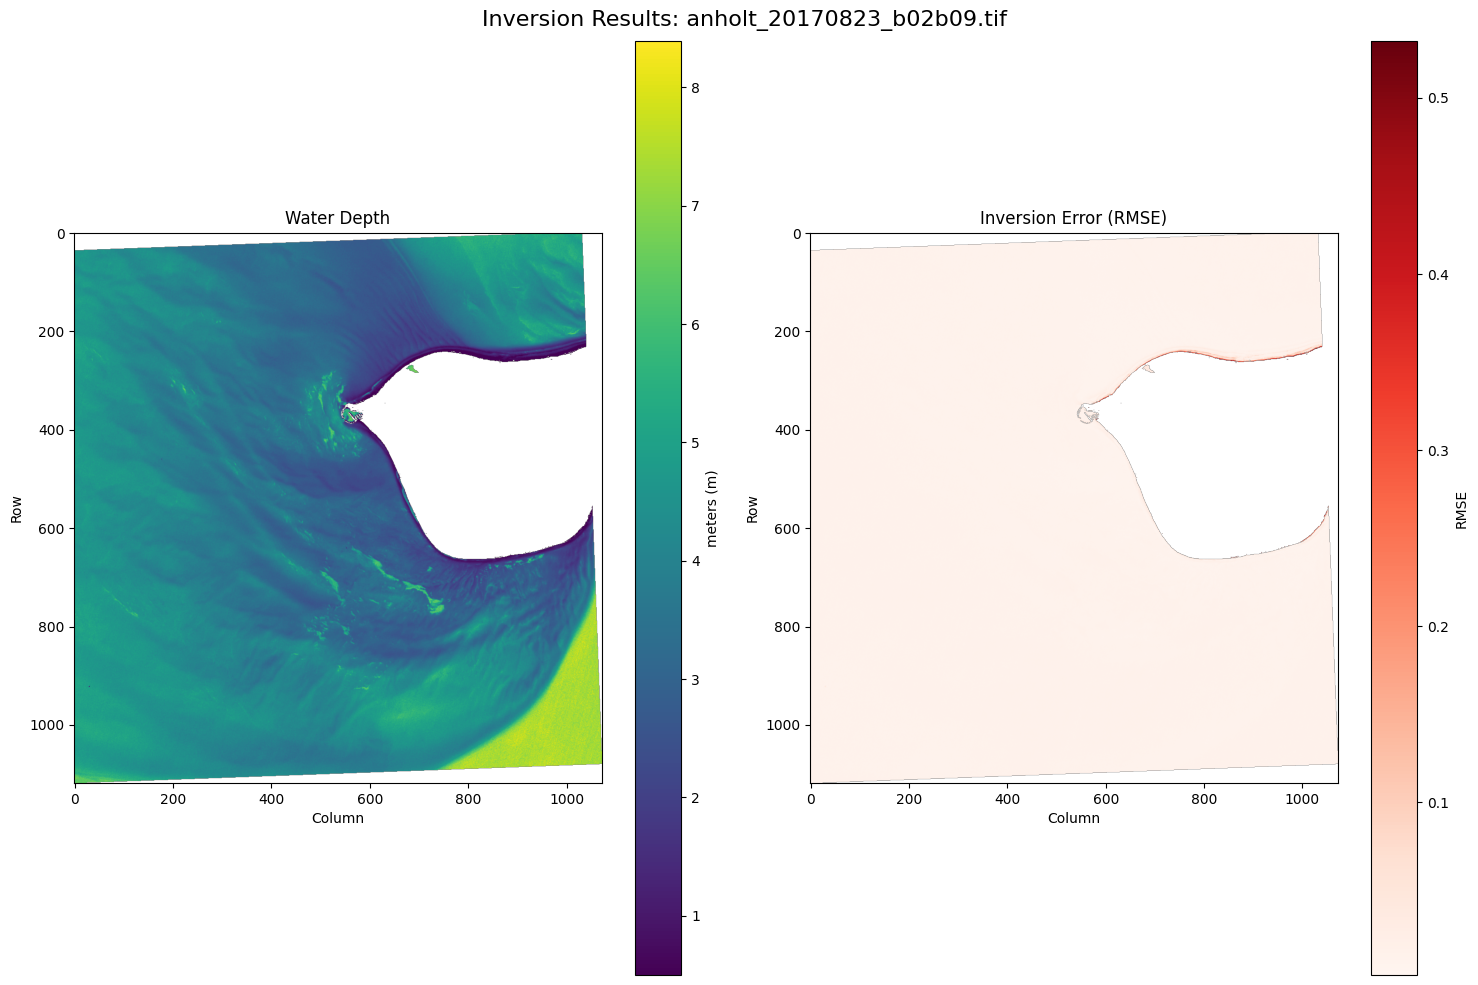

In [90]:
# Create comprehensive results object
print(f"💾 Saving results to: {output_dir}")

# Create ImageInversionResult object
result_obj = ImageInversionResult(
    results=results,
    image_metadata=image_data_obj.metadata,
    workflow_config=workflow.get_config(),
    image_path=str(image_path)
)

# Save in multiple formats
print(f"\n📁 Saving files...")

# 1. Save parameter maps as GeoTIFF
try:
    result_obj.save_all_parameters(str(output_dir), formats=['tiff'])
    print(f"   ✅ GeoTIFF files saved")
except Exception as e:
    print(f"   ⚠️ GeoTIFF save failed: {e}")

# 2. Save summary plot
try:
    summary_plot_path = output_dir / "bathymetry_summary.png"
    result_obj.plot_summary(save_path=str(summary_plot_path))
    print(f"   ✅ Summary plot saved: {summary_plot_path.name}")
except Exception as e:
    print(f"   ⚠️ Summary plot save failed: {e}")

# 3. Save processing metadata
metadata = {
    'processing_info': {
        'image_file': image_path.name,
        'processing_date': time.strftime('%Y-%m-%d %H:%M:%S'),
        'lut_build_time': build_time,
        'processing_time': process_time,
        'total_time': build_time + process_time,
        'lut_grid_size': grid_size,
        'n_processes': n_processes,
        'refinement': use_refinement
    },
    'results_summary': {
        'image_size': [width, height],
        'water_pixels': int(water_pixels),
        'valid_estimates': int(valid_pixels),
        'success_rate': float(success_rate),
        'depth_range': [float(valid_depths.min()), float(valid_depths.max())] if valid_pixels > 0 else [0, 0],
        'mean_depth': float(valid_depths.mean()) if valid_pixels > 0 else 0
    }
}

import json
metadata_path = output_dir / "processing_metadata.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)
print(f"   ✅ Metadata saved: {metadata_path.name}")

# 4. List all output files
output_files = list(output_dir.glob("*"))
print(f"\n📋 Output files ({len(output_files)} total):")
for file in sorted(output_files):
    size_mb = file.stat().st_size / (1024*1024) if file.is_file() else 0
    print(f"   📄 {file.name} ({size_mb:.1f} MB)")

print(f"\n✅ All results saved successfully!")
print(f"   📂 Output directory: {output_dir}")